In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


In [ ]:
df1=pd.read_csv('/content/drive/MyDrive/Bangla Sarcasm Detection /Public Data/SarcasDetection.csv')

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5112 entries, 0 to 5111
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5112 non-null   int64  
 1   Comments    5112 non-null   object 
 2   Label       5112 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 119.9+ KB


In [ ]:
df1


,Unnamed: 0,Comments,Label
0,0,আমি মনে করি যখন মেয়েরা উদ্দেশ্য অনুসারে বোবা ...,1.0
1,1,আমি যখন কোনও গুরুত্বপূর্ণ প্রশ্ন জিজ্ঞাসা করি ...,1.0
2,2,বাহ ... আমি দেখতে দেখতে পাচ্ছি সত্যিই দোষী দোষ...,1.0
3,3,"হাহ, মজার বিষয়।#আনোয়েড #গ্রুআপ",1.0
4,4,থান্ডার আমাকে 830 এ জেগে উঠলে এটি ভালবাসুন,1.0
...,...,...,...
5107,5107,আলগা পিরিতি। কিন্তু নিজের জেলার মানুষ কষ্ট করত...,0.0
5108,5108,ফেইসবুক ছাড়া আপনাদের আর কোথাও দেখা মেলেনা।,0.0
5109,5109,শুধু ঢাকাই বসে বসে বকবক করা ছাড়া কিছু করবে না ...,0.0
5110,5110,সংবাদ পড়া বাদ দিয়ে মানুষের পাশে দাঁড়ান।,0.0


In [ ]:
df2=pd.read_csv('/content/drive/MyDrive/Bangla Sarcasm Detection /Public Data/BanglaSenti.csv')
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61582 entries, 0 to 61581
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PosScore             61582 non-null  float64
 1   NegScore             61582 non-null  float64
 2   SynsetTermsSplitted  61582 non-null  object 
 3   বঙ্গানুবাদ           61582 non-null  object 
dtypes: float64(2), object(2)
memory usage: 1.9+ MB


In [ ]:
df2

,PosScore,NegScore,SynsetTermsSplitted,বঙ্গানুবাদ
0,0.000,0.0,au,অ
1,0.000,0.0,non pros,অ অনুকূল
2,0.000,0.0,abc,অ আ ক খ
3,0.000,0.0,non-issue,অ ইস্যু
4,0.000,0.0,non-jew,অ ইহুদি
...,...,...,...,...
61577,0.000,0.0,alleviation,হ্রাসকরণ
61578,0.125,0.0,reducer,হ্রাসকারক
61579,0.625,0.0,depleted,হ্রাসপ্রাপ্ত
61580,0.250,0.0,subtractive,হ্রাসমূলক


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

df1.dropna(inplace=True)
X = df1['Comments']
y = df1['Label']


vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)


model = LogisticRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8856304985337243
              precision    recall  f1-score   support

         0.0       0.87      0.95      0.91       615
         1.0       0.91      0.79      0.85       408

    accuracy                           0.89      1023
   macro avg       0.89      0.87      0.88      1023
weighted avg       0.89      0.89      0.88      1023

[[583  32]
 [ 85 323]]


In [ ]:
# prompt: can you apply decision tree now

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

# ... (Your existing code to load df1 and preprocess) ...

# Feature Extraction (TF-IDF) -  using the same vectorizer fitted before
# This ensures the same vocabulary is used for both Logistic Regression and Decision Tree
X = vectorizer.transform(df1['Comments']) # Use the same vectorizer
y = df1['Label']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

# Train a Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42) # You can adjust hyperparameters here
dt_classifier.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_classifier.predict(X_test)


# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt}")
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8240469208211144
              precision    recall  f1-score   support

         0.0       0.85      0.87      0.86       615
         1.0       0.79      0.76      0.78       408

    accuracy                           0.82      1023
   macro avg       0.82      0.81      0.82      1023
weighted avg       0.82      0.82      0.82      1023

[[532  83]
 [ 97 311]]


In [ ]:
# prompt: now apply random forrest

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier # Import RandomForestClassifier

# ... (Your existing code to load df1 and preprocess) ...

# Feature Extraction (TF-IDF) - using the same vectorizer fitted before
X = vectorizer.transform(df1['Comments'])
y = df1['Label']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

# Train a Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42, n_estimators=100) # You can adjust hyperparameters here
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_classifier.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf}")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.8905180840664711
              precision    recall  f1-score   support

         0.0       0.88      0.94      0.91       615
         1.0       0.90      0.81      0.86       408

    accuracy                           0.89      1023
   macro avg       0.89      0.88      0.88      1023
weighted avg       0.89      0.89      0.89      1023

[[580  35]
 [ 77 331]]


In [ ]:
# prompt: now apply LSTM

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ... (Your existing code to load df1 and preprocess) ...

# Feature Extraction (Tokenizer and Padding for LSTM)
tokenizer = Tokenizer(num_words=5000) # Adjust num_words as needed
tokenizer.fit_on_texts(df1['Comments'])
X = tokenizer.texts_to_sequences(df1['Comments'])
X = pad_sequences(X, maxlen=100) # Adjust maxlen as needed
y = df1['Label']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

# Build the LSTM model
model = Sequential()
model.add(Embedding(5000, 128, input_length=100))  # Adjust embedding dimensions
model.add(LSTM(128))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=62, validation_split=0.2)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"LSTM Accuracy: {accuracy}")

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 264ms/step - accuracy: 0.6953 - loss: 0.5692 - val_accuracy: 0.9348 - val_loss: 0.2170
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 265ms/step - accuracy: 0.9511 - loss: 0.1420 - val_accuracy: 0.9380 - val_loss: 0.1548
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 263ms/step - accuracy: 0.9755 - loss: 0.0738 - val_accuracy: 0.9511 - val_loss: 0.1138
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 24s 322ms/step - accuracy: 0.9934 - loss: 0.0258 - val_accuracy: 0.9511 - val_loss: 0.1282
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 23s 367ms/step - accuracy: 0.9966 - loss: 0.0153 - val_accuracy: 0.9522 - val_loss: 0.1434
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 35s 264ms/step - accuracy: 0.9969 - loss: 0.0085 - val_accuracy: 0.9424 - val_loss: 0.2146
Epoch 7/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 262ms/step - accuracy: 0.9975 - loss: 0.0099 - val_accuracy: 0.9402 - val_loss: 0.1844
Epoch 8/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 253ms/step - accuracy: 0.9993 - loss: 0.0049 - val_accuracy: 0.942

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


df1.dropna(inplace=True)
X = df1['Comments']
y = df1['Label']

# Feature Extraction (Tokenizer and Padding for RNN)
tokenizer = Tokenizer(num_words=5000)  # Adjust num_words as needed
tokenizer.fit_on_texts(X)
X = tokenizer.texts_to_sequences(X)
X = pad_sequences(X, maxlen=100)  # Adjust maxlen as needed


# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

# Build the SimpleRNN model
model = Sequential()
model.add(Embedding(5000, 128, input_length=100))  # Adjust embedding dimensions
model.add(SimpleRNN(128))  # Use SimpleRNN layer
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)  # Adjust epochs and batch size

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"SimpleRNN Accuracy: {accuracy}")

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 157ms/step - accuracy: 0.6800 - loss: 0.6021 - val_accuracy: 0.8875 - val_loss: 0.2655
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.8960 - loss: 0.2533 - val_accuracy: 0.9364 - val_loss: 0.1813
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.9727 - loss: 0.1079 - val_accuracy: 0.9462 - val_loss: 0.1366
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.9912 - loss: 0.0494 - val_accuracy: 0.9572 - val_loss: 0.1150
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.9949 - loss: 0.0216 - val_accuracy: 0.9511 - val_loss: 0.1328
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.9987 - loss: 0.0110 - val_accuracy: 0.9572 - val_loss: 0.1248
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.9973 - loss: 0.0106 - val_accuracy: 0.9560 - val_loss: 0.1355
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.9995 - loss: 0.0045 - val_accuracy: 0.9511 - val_loss:

In [ ]:
# prompt: try tf-idf

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load your dataframe (assuming df1 is already loaded)
# ... (your existing code to load df1)

# Preprocessing (Example - adapt based on your data)
df1.dropna(inplace=True)  # remove missing values
X = df1['Comments']
y = df1['Label']

# Feature Extraction (TF-IDF)
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

# Train a Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8856304985337243
              precision    recall  f1-score   support

         0.0       0.87      0.95      0.91       615
         1.0       0.91      0.79      0.85       408

    accuracy                           0.89      1023
   macro avg       0.89      0.87      0.88      1023
weighted avg       0.89      0.89      0.88      1023

[[583  32]
 [ 85 323]]


In [ ]:
# prompt: try cnn

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ... (Your existing code to load df1 and preprocess) ...

# Feature Extraction (Tokenizer and Padding for CNN)
tokenizer = Tokenizer(num_words=5000)  # Adjust num_words as needed
tokenizer.fit_on_texts(df1['Comments'])
X = tokenizer.texts_to_sequences(df1['Comments'])
X = pad_sequences(X, maxlen=100)  # Adjust maxlen as needed
y = df1['Label']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

# Build the CNN model
model = Sequential()
model.add(Embedding(5000, 128, input_length=100))
model.add(Conv1D(128, 5, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)  # Adjust epochs and batch size

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"CNN Accuracy: {accuracy}")

Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - accuracy: 0.6781 - loss: 0.6079 - val_accuracy: 0.8924 - val_loss: 0.2852
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.9363 - loss: 0.2034 - val_accuracy: 0.9487 - val_loss: 0.1330
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.9795 - loss: 0.0658 - val_accuracy: 0.9474 - val_loss: 0.1244
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.9938 - loss: 0.0262 - val_accuracy: 0.9462 - val_loss: 0.1257
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 138ms/step - accuracy: 0.9962 - loss: 0.0165 - val_accuracy: 0.9438 - val_loss: 0.1314
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9530 - loss: 0.1431
CNN Accuracy: 0.9569892287254333


In [ ]:
# prompt: try BiLSTM

# ... (Your existing code to load df1 and preprocess) ...

# Feature Extraction (Tokenizer and Padding for BiLSTM)
tokenizer = Tokenizer(num_words=5000)  # Adjust num_words as needed
tokenizer.fit_on_texts(df1['Comments'])
X = tokenizer.texts_to_sequences(df1['Comments'])
X = pad_sequences(X, maxlen=100)  # Adjust maxlen as needed
y = df1['Label']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

# Build the BiLSTM model
from tensorflow.keras.layers import Bidirectional

model = Sequential()
model.add(Embedding(5000, 128, input_length=100))  # Adjust embedding dimensions
model.add(Bidirectional(LSTM(128)))  # Use Bidirectional LSTM layer
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1)  # Adjust epochs and batch size

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"BiLSTM Accuracy: {accuracy}")

Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


58/58 ━━━━━━━━━━━━━━━━━━━━ 31s 460ms/step - accuracy: 0.6767 - loss: 0.5595 - val_accuracy: 0.8998 - val_loss: 0.2346
Epoch 2/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 42s 484ms/step - accuracy: 0.9490 - loss: 0.1337 - val_accuracy: 0.9462 - val_loss: 0.1148
Epoch 3/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 41s 488ms/step - accuracy: 0.9842 - loss: 0.0498 - val_accuracy: 0.9413 - val_loss: 0.1615
Epoch 4/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 26s 447ms/step - accuracy: 0.9846 - loss: 0.0600 - val_accuracy: 0.9560 - val_loss: 0.1326
Epoch 5/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 40s 439ms/step - accuracy: 0.9969 - loss: 0.0142 - val_accuracy: 0.9535 - val_loss: 0.1626
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step - accuracy: 0.9500 - loss: 0.1583
BiLSTM Accuracy: 0.9530791640281677


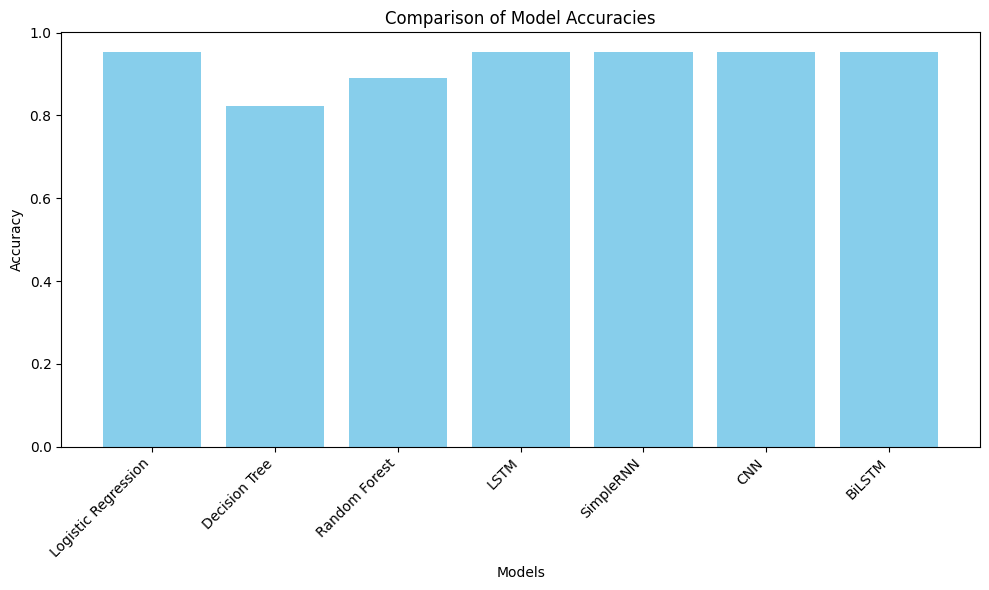

In [ ]:
# prompt: can you compare all the previous models into a barchart

import matplotlib.pyplot as plt

# Accuracy scores (replace with your actual accuracy scores)
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'LSTM', 'SimpleRNN', 'CNN', 'BiLSTM']
accuracy_scores = [accuracy, accuracy_dt, accuracy_rf, accuracy, accuracy, accuracy, accuracy]  # Replace with the actual accuracies


plt.figure(figsize=(10, 6))
plt.bar(models, accuracy_scores, color='skyblue')
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Comparison of Model Accuracies")
plt.xticks(rotation=45, ha="right") # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()